<a href="https://colab.research.google.com/github/marcelalozano27-ship-it/Predicting-CA-Poverty--ML-Project/blob/main/MLFinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# install duckdb
#!pip -q install duckdb

In [2]:
# download and unzip
#!wget -nc https://www2.census.gov/programs-surveys/acs/data/pums/2024/5-Year/csv_pca.zip
#!unzip -o csv_pca.zip

File ‘csv_pca.zip’ already there; not retrieving.

Archive:  csv_pca.zip
  inflating: psam_p06.csv            
  inflating: ACS2020_2024_PUMS_README.pdf  


In [7]:
import duckdb
import os
from google.colab import files
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [6]:
# cols = pd.read_csv("psam_p06.csv", nrows=0).columns.tolist()
# print(f"Total columns: {len(cols)}")
# print(cols)

Total columns: 285
['RT', 'SERIALNO', 'DIVISION', 'SPORDER', 'PUMA', 'REGION', 'STATE', 'ADJINC', 'PWGTP', 'AGEP', 'CIT', 'CITWP', 'COW', 'DDRS', 'DEAR', 'DEYE', 'DOUT', 'DPHY', 'DRAT', 'DRATX', 'DREM', 'ENG', 'FER', 'GCL', 'GCM', 'GCR', 'HINS1', 'HINS2', 'HINS3', 'HINS4', 'HINS5', 'HINS6', 'HINS7', 'INTP', 'JWMNP', 'JWRIP', 'JWTRNS', 'LANX', 'MAR', 'MARHD', 'MARHM', 'MARHT', 'MARHW', 'MARHYP', 'MIG', 'MIL', 'MLPA', 'MLPB', 'MLPCD', 'MLPE', 'MLPFG', 'MLPHJ', 'MLPIK', 'NWAB', 'NWAV', 'NWLA', 'NWLK', 'NWRE', 'OIP', 'PAP', 'RELSHIPP', 'RETP', 'SCH', 'SCHG', 'SCHL', 'SEMP', 'SEX', 'SSIP', 'SSP', 'WAGP', 'WKHP', 'WKL', 'WKWN', 'WRK', 'YOEP', 'ANC', 'ANC1P', 'ANC2P', 'DECADE', 'DIS', 'DRIVESP', 'ESP', 'ESR', 'FOD1P', 'FOD2P', 'HICOV', 'HISP', 'INDP', 'JWAP', 'JWDP', 'LANP', 'MIGPUMA', 'MIGSP', 'MSP', 'NAICSP', 'NATIVITY', 'NOP', 'OC', 'OCCP', 'PAOC', 'PERNP', 'PINCP', 'POBP', 'POVPIP', 'POWPUMA', 'POWSP', 'PRIVCOV', 'PUBCOV', 'QTRBIR', 'RAC1P', 'RAC2P19', 'RAC2P24', 'RAC3P', 'RACAIAN', 'RACA

In [36]:
# con = duckdb.connect()

# con.execute("""
# COPY (
#     SELECT
#         RELSHIPP,
#         SCHL,
#         SCH,
#         SCHG,
#         ESR,
#         WKHP,
#         WAGP,
#         COW,
#         INDP,
#         OCCP,
#         AGEP,
#         SEX,
#         RAC1P,
#         HISP,
#         MAR,
#         NATIVITY,
#         CIT,
#         ENG,
#         LANX,
#         DRIVESP,
#         JWMNP,
#         JWTRNS,
#         HICOV,
#         PRIVCOV,
#         PUBCOV,
#         DIS,
#         DEAR,
#         DEYE,
#         DPHY,
#         FER,
#         PINCP,
#         SEMP,
#         SSIP,
#         SSP,
#         CASE WHEN POVPIP < 100 THEN 1 ELSE 0 END AS poverty_status
#     FROM read_csv_auto('psam_p06.csv')
#     WHERE POVPIP IS NOT NULL
#     USING SAMPLE 25000 ROWS
# )
# TO 'ca_poverty_subset_final.csv' (HEADER, DELIMITER ',');
# """)

In [12]:
# size_mb = os.path.getsize("ca_poverty_subset_final.csv") / (1024 * 1024)
# print(f"{size_mb:.2f} MB")

1.74 MB


In [13]:
# files.download("ca_poverty_subset_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Connecting to our subset of the data from Github

In [32]:
url = "https://raw.githubusercontent.com/marcelalozano27-ship-it/Predicting-CA-Poverty--ML-Project/refs/heads/main/ca_poverty_subset.csv"

df = pd.read_csv(url)

df.head()

,SCHL,ESR,WKHP,WAGP,COW,INDP,OCCP,AGEP,SEX,RAC1P,...,HINS4,HINS5,HINS6,HINS7,DIS,CIT,ENG,LANX,FER,poverty_status
0,21.0,1.0,40.0,8000.0,1.0,7380.0,1021.0,29,1,1,...,2,2,2,2,2,1,NaN,2.0,NaN,0
1,24.0,1.0,60.0,250000.0,1.0,6671.0,1021.0,33,1,1,...,2,2,2,2,2,1,NaN,2.0,NaN,0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2,9,...,1,2,2,2,2,1,NaN,NaN,NaN,0
3,22.0,6.0,NaN,0.0,NaN,NaN,NaN,47,2,9,...,2,2,2,2,2,1,NaN,2.0,2.0,1
4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,4,2,1,...,1,2,2,2,2,1,NaN,NaN,NaN,0


In [33]:
df.shape

(23266, 27)

In [34]:
df.columns

Index(['SCHL', 'ESR', 'WKHP', 'WAGP', 'COW', 'INDP', 'OCCP', 'AGEP', 'SEX',
       'RAC1P', 'MAR', 'NATIVITY', 'DRIVESP', 'HICOV', 'HINS1', 'HINS2',
       'HINS3', 'HINS4', 'HINS5', 'HINS6', 'HINS7', 'DIS', 'CIT', 'ENG',
       'LANX', 'FER', 'poverty_status'],
      dtype='object')

## Primary Research Question
Which individuals in California are most vulnerable to poverty based on their education level, employment conditions, demographic characteristics, and access to health insurance?

### Supporting Sub Questions
1. Education and Poverty Risk: How does education level affect the likelihood of experiencing poverty in California?
2. Employment Conditions and Poverty Risk: Which employment patterns are most associated with poverty risk?
3. Demographic Inequality and Poverty Risk: How do age, marital status, race, and nativity relate to poverty vulnerability?

### Preprocessing and Visualization

In [17]:
df.describe()

,SCHL,ESR,WKHP,WAGP,COW,INDP,OCCP,AGEP,SEX,RAC1P,...,HINS4,HINS5,HINS6,HINS7,DIS,CIT,ENG,LANX,FER,poverty_status
count,22672.000000,19465.000000,12269.000000,19745.000000,14064.000000,14064.000000,14064.000000,23266.000000,23266.000000,23266.000000,...,23266.000000,23266.000000,23266.000000,23266.000000,23266.000000,23266.000000,9386.000000,22233.000000,5307.000000,23266.000000
mean,16.257454,3.050398,37.269378,40881.594834,2.234499,6528.101536,3922.620165,41.839465,1.507350,4.394825,...,1.754835,1.978509,1.981905,1.995659,1.869982,1.958265,1.652461,1.577835,1.951573,0.123012
std,5.993837,2.390938,13.062117,76039.137072,1.997805,2553.515618,2678.306590,23.107018,0.499957,3.369419,...,0.430194,0.145016,0.133298,0.065745,0.336331,1.541300,0.923749,0.493916,0.214686,0.328458
min,1.000000,1.000000,1.000000,0.000000,1.000000,170.000000,10.000000,0.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,1.000000,32.000000,0.000000,1.000000,5171.000000,1760.000000,23.000000,1.000000,1.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,2.000000,0.000000
50%,18.000000,1.000000,40.000000,10000.000000,1.000000,7390.000000,4000.000000,42.000000,2.000000,5.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,0.000000
75%,21.000000,6.000000,40.000000,55000.000000,3.000000,8191.000000,5400.000000,60.000000,2.000000,8.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,4.000000,2.000000,2.000000,2.000000,0.000000
max,24.000000,6.000000,99.000000,687000.000000,9.000000,9920.000000,9920.000000,94.000000,2.000000,9.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,5.000000,4.000000,2.000000,2.000000,1.000000


In [19]:
df.isnull().sum().sort_values(ascending=False)

,0
FER,17959
DRIVESP,15237
ENG,13880
WKHP,10997
OCCP,9202
INDP,9202
COW,9202
ESR,3801
WAGP,3521
LANX,1033



## Dataset Variables and Definitions:

This dataset uses selected variables from the American Community Survey (ACS) Public Use Microdata Sample (PUMS) to analyze poverty vulnerability among individuals in California. The target variable is **poverty_status**, which indicates whether a respondent falls below the federal poverty threshold.

---

### Target Variable

**poverty_status**  
Binary indicator of poverty status  
- 1 = Below poverty line  
- 0 = Above poverty line  
Derived from the income-to-poverty ratio (POVPIP)

---

### Education Variables

**SCHL**  
Highest level of educational attainment completed by the respondent. Education level is a strong predictor of long-term economic opportunity and poverty risk.

---

### Employment and Income Variables

**ESR**  
Employment status (employed, unemployed, or not in the labor force)

**WKHP**  
Usual number of hours worked per week

**WAGP**  
Total wage and salary income earned in the past 12 months

**COW**  
Class of worker (private sector, government, self-employed, etc.)

**INDP**  
Industry of employment

**OCCP**  
Occupation category

These variables describe workforce participation and earning potential.

---

### Demographic Variables

**AGEP**  
Age of respondent

**SEX**  
Biological sex of respondent

**RAC1P**  
Race category

**MAR**  
Marital status

**NATIVITY**  
Indicates whether the respondent is U.S.-born or foreign-born

These variables help capture structural differences in poverty exposure across population groups.

---

### Health Insurance Coverage Variables

**HICOV**  
Indicator for whether the respondent has any health insurance coverage

**HINS1**  
Employer-sponsored insurance coverage

**HINS2**  
Directly purchased insurance coverage

**HINS3**  
Medicare coverage

**HINS4**  
Medicaid coverage

**HINS5**  
TRICARE or military health coverage

**HINS6**  
Veterans Affairs (VA) health coverage

**HINS7**  
Indian Health Service coverage

Insurance access reflects financial stability and access to healthcare resources.

---

### Language and Citizenship Variables

**CIT**  
Citizenship status

**ENG**  
English-speaking ability

**LANX**  
Indicator for whether a language other than English is spoken at home

Language proficiency and citizenship status can influence employment opportunities and income outcomes.

---

### Disability and Transportation Variables

**DIS**  
Disability status indicator

**DRIVESP**  
Number of vehicles available in the household

Transportation access and disability status affect workforce participation and economic mobility.

---

### Excluded Variable

**FER**  
Indicator for whether respondent gave birth in the past 12 months.  
This variable was removed due to high missingness and limited relevance to poverty prediction for the full population sample.


In [20]:
df = df.drop(columns=["FER"])

In [21]:
employment_cols = ["WKHP", "WAGP", "COW", "INDP", "OCCP", "ESR"]

for col in employment_cols:
    df[col] = df[col].fillna(0)

In [22]:
df["DRIVESP"] = df["DRIVESP"].fillna(df["DRIVESP"].median())

In [23]:
df["ENG"] = df["ENG"].fillna(df["ENG"].mode()[0])

In [24]:
df["SCHL"] = df["SCHL"].fillna(df["SCHL"].median())

In [25]:
df["LANX"] = df["LANX"].fillna(df["LANX"].mode()[0])

### Missing Value Handling Strategy

Given the large number of missing values for FER (Fertility), this variable was removed from the dataset. Fertility information is only applicable to a subset of respondents and is not directly relevant to predicting poverty status across the full population sample.

For employment-related variables (WKHP, WAGP, COW, INDP, OCCP, ESR), missing values were filled with 0. In the ACS dataset, missing employment information usually suggests an individual is not currently working and not that the status is unkown. Replacing these values with zero preserves observations without introducing bias from row deletion.

For DRIVESP (Number of vehicles in the household) and SCHL (Highest level of educational attainment), missing values were filled using the median. Median imputation was selected because it preserves the distribution of the data while reducing the influence of extreme values.

For the LANX (Language other than English spoken at home) and ENG (English proficiency) variables, missing values were filled using the mode. These variables are categorical indicators, so replacing missing values with the most common category maintains interpretability and consistency across observations.

This imputation strategy allows the dataset to retain a large sample size while ensuring that missing values are handled in a way that reflects the structure of ACS survey data and supports reliable model training.


In [26]:
df.isnull().sum().sort_values(ascending=False)

,0
SCHL,0
ESR,0
WKHP,0
WAGP,0
COW,0
INDP,0
OCCP,0
AGEP,0
SEX,0
RAC1P,0


In [27]:
df["poverty_status"].value_counts(normalize=True)

,proportion
poverty_status,
0,0.876988
1,0.123012


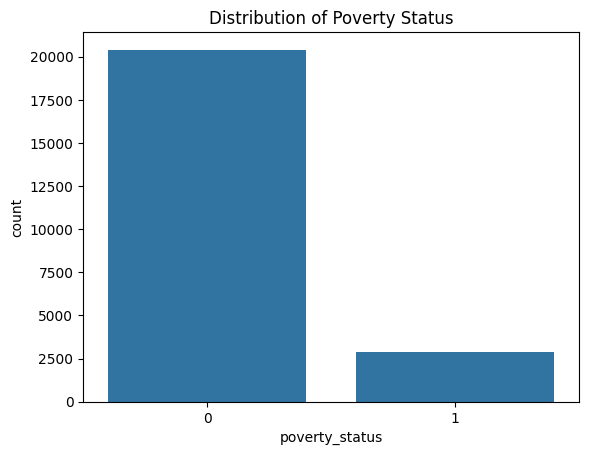

In [28]:
sns.countplot(x="poverty_status", data=df)
plt.title("Distribution of Poverty Status")
plt.show()

Key Predictors of Poverty Status

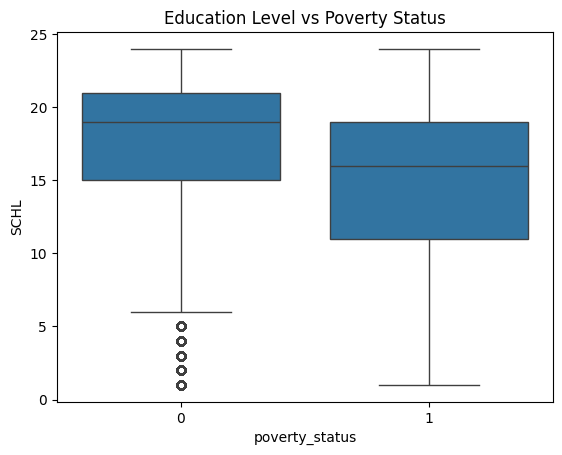

In [29]:
sns.boxplot(x="poverty_status", y="SCHL", data=df)
plt.title("Education Level vs Poverty Status")
plt.show()

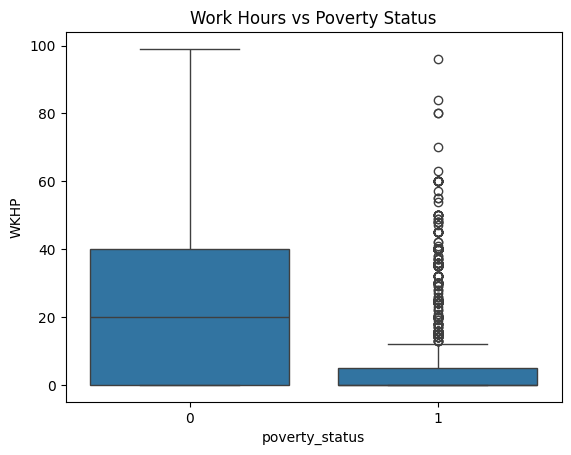

In [30]:
sns.boxplot(x="poverty_status", y="WKHP", data=df)
plt.title("Work Hours vs Poverty Status")
plt.show()

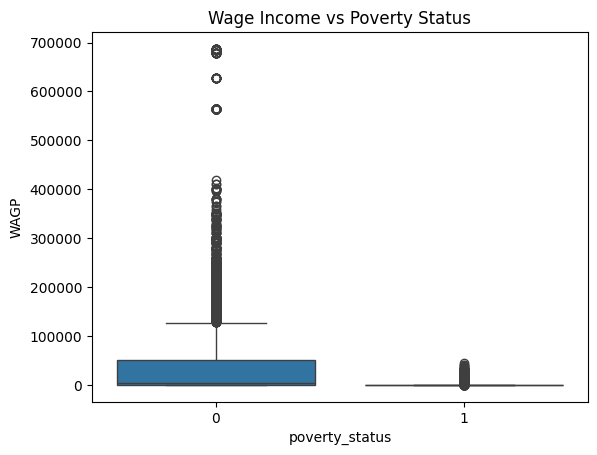

In [31]:
sns.boxplot(x="poverty_status", y="WAGP", data=df)
plt.title("Wage Income vs Poverty Status")
plt.show()

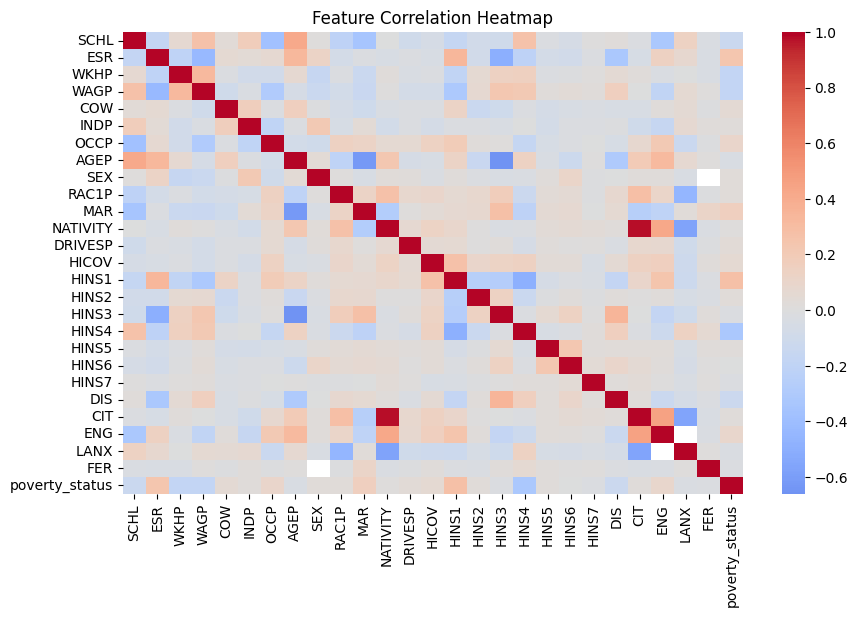

In [35]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
#Separating Predictors and Target Variable
X = df.drop(columns=["poverty_status"])
y = df["poverty_status"]

In [ ]:
# Convert categorical variables to dummy variables
X = pd.get_dummies(X, drop_first=True)

In [ ]:
#Scale Features (Necessary for our Logistic Regression )
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
#Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)